<a href="https://colab.research.google.com/github/jaweller/derin-ogrenme/blob/main/derinogrenmemidterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install opendatasets
# Gerekli Kütüphaneler
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn metrikleri ve veri ayırma
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# TensorFlow ve Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Veri setini indirmek için (Kaggle username ve key isteyecektir)
import opendatasets as od

# Veri Seti Yükleme
dataset_url = 'https://www.kaggle.com/datasets/omkargurav/face-mask-dataset'
od.download(dataset_url)

# Veri yollarını hazırlama
dataset_dir = './face-mask-dataset/data'

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ertugrulkuyumcu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset


100%|██████████| 163M/163M [00:00<00:00, 230MB/s]


In [5]:
# Dosya yollarını ve etiketleri toplama
filepaths = []
labels = []

for label in os.listdir(dataset_dir):
    label_dir = os.path.join(dataset_dir, label)
    if os.path.isdir(label_dir):
        for image_file in os.listdir(label_dir):
            filepaths.append(os.path.join(label_dir, image_file))
            labels.append(label) # 'with_mask' veya 'without_mask'

df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# Toplam verinin %20’si test, %80’i eğitim/validasyon
train_val_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])

# Eğitim/validasyon verisinin %80’i eğitim, %20’si validasyon
train_df, val_df = train_test_split(train_val_df, test_size=0.20, random_state=42, stratify=train_val_df['label'])

print(f"Eğitim seti boyutu: {len(train_df)}")
print(f"Validasyon seti boyutu: {len(val_df)}")
print(f"Test seti boyutu: {len(test_df)}")

# Görüntü boyutları
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Eğitim verisi için Veri Arttırımı (Data Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validasyon ve Test için SADECE ölçeklendirme (rescale)
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

# Generatorlerin oluşturulması
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Eğitim seti boyutu: 4833
Validasyon seti boyutu: 1209
Test seti boyutu: 1511
Found 4833 validated image filenames belonging to 2 classes.
Found 1209 validated image filenames belonging to 2 classes.
Found 1511 validated image filenames belonging to 2 classes.


In [6]:
# MobileNet (V1) Base Model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

# Kendi katmanlarımızı ekliyoruz
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x) # 1. Dense Katmanı
x = Dense(128, activation='relu')(x) # 2. Dense Katmanı
predictions = Dense(2, activation='softmax')(x) # Çıktı katmanı (2 sınıf: maskeli, maskesiz)

model = Model(inputs=base_model.input, outputs=predictions)

# Optimizer, Loss ve Metrics ayarları
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callback'lerin tanımlanması
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)
model_checkpoint = ModelCheckpoint('best_mask_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# Modelin Eğitilmesi
EPOCHS = 100

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.9343 - loss: 0.1757

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 1: val_loss improved from None to 0.11055, saving model to best_mask_model.h5



Epoch 1: finished saving model to best_mask_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 149s 704ms/step - accuracy: 0.9727 - loss: 0.0829 - val_accuracy: 0.9744 - val_loss: 0.1105 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9861 - loss: 0.0404
Epoch 2: val_loss did not improve from 0.11055
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 439ms/step - accuracy: 0.9872 - loss: 0.0403 - val_accuracy: 0.9007 - val_loss: 0.5560 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9848 - loss: 0.0459
Epoch 3: val_loss did not improve from 0.11055
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 434ms/step - accuracy: 0.9783 - loss: 0.0678 - val_accuracy: 0.8677 - val_loss: 1.3665 - learning_rate: 0.0010
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9843 - loss: 0.0521
Epoch 4: val_loss improved from 0.11055 to 0.01373, saving model to best_mask_model.h5



Epoch 4: finished saving model to best_mask_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 438ms/step - accuracy: 0.9882 - loss: 0.0363 - val_accuracy: 0.9959 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9938 - loss: 0.0186
Epoch 5: val_loss did not improve from 0.01373
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 443ms/step - accuracy: 0.9928 - loss: 0.0246 - val_accuracy: 0.9851 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9792 - loss: 0.0804
Epoch 6: val_loss did not improve from 0.01373
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 437ms/step - accuracy: 0.9816 - loss: 0.0744 - val_accuracy: 0.9545 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9907 - loss: 0.0370
Epoch 7: val_loss did not improve from 0.01373
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 438ms/step - accuracy: 0.9915 - loss: 0.0310 - val_accuracy: 0.9942 - val


Epoch 13: finished saving model to best_mask_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 440ms/step - accuracy: 0.9990 - loss: 0.0065 - val_accuracy: 0.9950 - val_loss: 0.0119 - learning_rate: 1.0000e-04
Epoch 14/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9982 - loss: 0.0068
Epoch 14: val_loss did not improve from 0.01191
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 434ms/step - accuracy: 0.9977 - loss: 0.0060 - val_accuracy: 0.9950 - val_loss: 0.0146 - learning_rate: 1.0000e-04
Epoch 15/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9978 - loss: 0.0054
Epoch 15: val_loss did not improve from 0.01191
152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 433ms/step - accuracy: 0.9977 - loss: 0.0057 - val_accuracy: 0.9967 - val_loss: 0.0122 - learning_rate: 1.0000e-04
Epoch 16/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9979 - loss: 0.0063
Epoch 16: val_loss improved from 0.01191 to 0.00827, saving model to best_mask_model.h5



Epoch 16: finished saving model to best_mask_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 441ms/step - accuracy: 0.9975 - loss: 0.0069 - val_accuracy: 0.9967 - val_loss: 0.0083 - learning_rate: 1.0000e-04
Epoch 17/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9988 - loss: 0.0095
Epoch 17: val_loss did not improve from 0.00827
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 437ms/step - accuracy: 0.9981 - loss: 0.0066 - val_accuracy: 0.9959 - val_loss: 0.0098 - learning_rate: 1.0000e-04
Epoch 18/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9993 - loss: 0.0029
Epoch 18: val_loss improved from 0.00827 to 0.00638, saving model to best_mask_model.h5



Epoch 18: finished saving model to best_mask_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 438ms/step - accuracy: 0.9979 - loss: 0.0056 - val_accuracy: 0.9983 - val_loss: 0.0064 - learning_rate: 1.0000e-04
Epoch 19/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9981 - loss: 0.0057
Epoch 19: val_loss did not improve from 0.00638
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 439ms/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9967 - val_loss: 0.0072 - learning_rate: 1.0000e-04
Epoch 20/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9997 - loss: 0.0024
Epoch 20: val_loss did not improve from 0.00638
152/152 ━━━━━━━━━━━━━━━━━━━━ 70s 459ms/step - accuracy: 0.9992 - loss: 0.0032 - val_accuracy: 0.9959 - val_loss: 0.0105 - learning_rate: 1.0000e-04
Epoch 21/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9990 - loss: 0.0031
Epoch 21: val_loss did not improve from 0.00638
152/152 ━━━━━━━━━━━━━━━━━━━━ 67s 439ms/step - accuracy: 0.9990 - loss: 0.0027 - val_acc

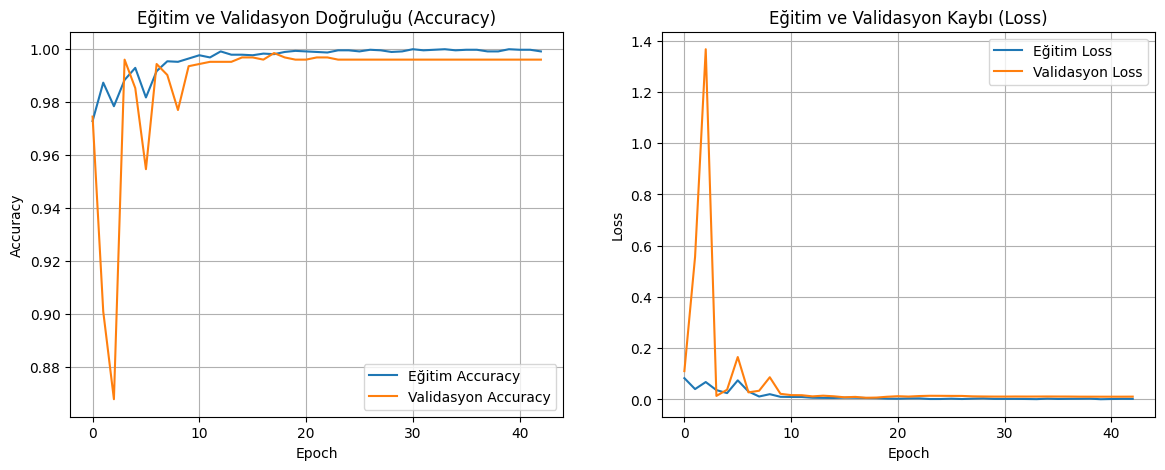

In [7]:
# Accuracy ve Loss Grafiklerini Çizdirme
plt.figure(figsize=(14, 5))

# Accuracy Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Validasyon Accuracy')
plt.title('Eğitim ve Validasyon Doğruluğu (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Validasyon Loss')
plt.title('Eğitim ve Validasyon Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 278ms/step


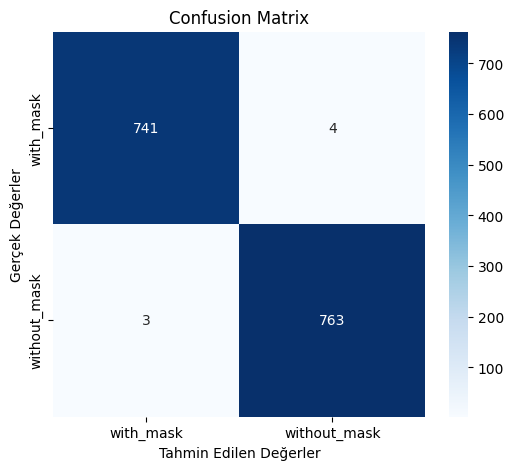

--- MODEL PERFORMANS METRİKLERİ ---
Accuracy (Doğruluk):  0.9954
Precision (Duyarlılık): 0.9948
Recall (Hassasiyet):    0.9961
Specificity (Özgüllük): 0.9946
F1-score:               0.9954


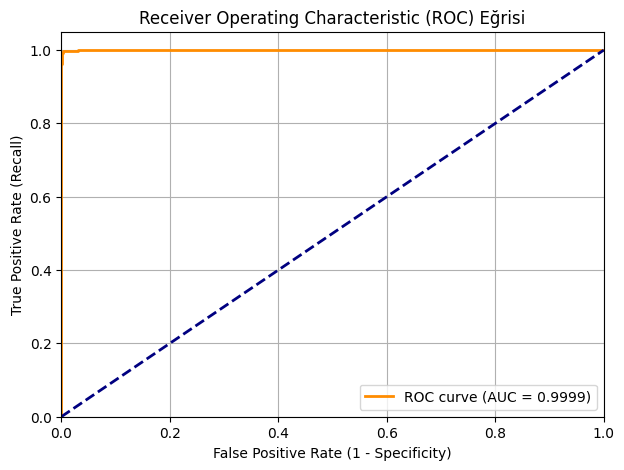

In [8]:
# Tahminlerin alınması
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

# 1. Confusion Matrix (Karışıklık Matrisi)
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Metriklerin Hesaplanması
# cm.ravel() = tn, fp, fn, tp (Binary classification yapısına göre ayarlanır)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)
specificity = tn / (tn + fp)

print("--- MODEL PERFORMANS METRİKLERİ ---")
print(f"Accuracy (Doğruluk):  {accuracy:.4f}")
print(f"Precision (Duyarlılık): {precision:.4f}")
print(f"Recall (Hassasiyet):    {recall:.4f}")
print(f"Specificity (Özgüllük): {specificity:.4f}")
print(f"F1-score:               {f1:.4f}")

# 2. ROC Eğrisi ve AUC Hesabı
# Binary yapı için maskeli/maskesiz olasılıklarından birini seçiyoruz (1 sınıfının olasılığı)
y_pred_prob = Y_pred[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Eğrisi')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()